In [1]:
import warnings
import copy

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import anndata as ad
import pertpy as pt
import scanpy as sc
import numpy as np
import pandas as pd
import math
import seaborn as sns

sccoda_model = pt.tl.Sccoda()

In [2]:
adata_age_cd4= sc.read_h5ad("/scratch/user/s4575250/BIOX7018_thesis/write/03_batch_expression/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_combined_annot_with_age_scvi.h5ad")

In [3]:
adata_age_cd4

AnnData object with n_obs × n_vars = 552283 × 2889
    obs: 'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collect

In [4]:
adata_age_cd4.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      141666
4–6      123469
7–10      84101
11–14    151034
15–18     52013
Name: count, dtype: int64

In [5]:
adata_age_cd4.obs['cell_type'].unique()
adata_age_cd4.obs['cell_type'].value_counts()

cell_type
Naive/Central memory CD4 T cell    352568
CCR4+ CCR6+ memory CD4 T cell       32809
TOX+ CD4 T cell                     25003
Tfh                                 22711
Tfh cell                            21688
Th2 cell                            18195
Th2-like T cell                     17054
TIGIT+ TOX+ memory CD4 T cell       16203
CCR6+ memory CD4 T cell             15731
CCR6+ CD4 T cell                     7431
CTLA4+ TOX+ CD4 T cell               7049
CCR4+ CD4 T cell                     5546
Treg                                 2566
Cytotoxic CD4 T cell                 2436
Th2                                  2333
CCR4+ memory CD4 T cell              2186
Unknown CD4 T cell                    559
Innate-like CD4 T cell                165
Regulatory T cell                      50
Name: count, dtype: int64

In [6]:
adata_age_cd4.obs["Age_group"] = pd.Categorical(
        adata_age_cd4.obs["Age_group"],
        categories=["0–3", "4–6", "7–10", "11–14", "15–18"],
        ordered=True,
    )

In [7]:
adata_age_cd4.obs["Age_group"].value_counts().sort_index()

Age_group
0–3      141666
4–6      123469
7–10      84101
11–14    151034
15–18     52013
Name: count, dtype: int64

In [7]:
adata_age_cd4.obs["Child's sex"] = adata_age_cd4.obs["Child's sex"].astype("category")

In [8]:
# build sccoda input from cell-level data
def make_sccoda_from_lineage(
    adata,
    cell_type_col="cell_type",   
    sample_col="pica_id",       
    covariates=("Age_group","Child's sex"), 
):
    sccoda_data = sccoda_model.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=cell_type_col,
        sample_identifier=sample_col,
        covariate_obs=list(covariates),
    )
    return sccoda_data

In [9]:
sccoda_cd4 = make_sccoda_from_lineage(adata_age_cd4, cell_type_col="cell_type")

In [10]:
sccoda_cd4

MuData object with n_obs × n_vars = 552411 × 2908
  2 modalities
    rna:	552283 x 2889
      obs:	'status', 'assignment', 'pica_id', 'pool_id', 'sequencing_batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'status_manual', 'cell_type', 'broad_cell_type', 'pica_broad_cell_type', 'pica_cell_type', 'pica_cell_type_01_myeloid', 'pica_cell_type_02_b', 'pica_cell_type_03_nk_t', 'pica_cell_type_complete', 'pica_broad_cell_type_complete', 'pica_broad_cell_type_complete_01_gdT_corrected', 'pica_cell_type_complete_01_gdT_corrected', 'status_manual_01_pica', 'Record ID', 'Event Name', 'Was baseline blood sample collected?', 'IFC ID', "Child's sex", 'Age in years at the time of collection', 'Age in months at the time of collection', '1) Does your child have any significant health issue or condition?', 'Date and time of blood collection', '4) Does your child have any allergies diagnosed by a medical practitioner?', '5) Has your child shown any allergic symptoms within the last 2 months?', '7) Is your child on any medication? (including immune-modulating medications like steroids in the last two weeks)?', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=No)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Child)', '6) Does your child or your family have any history of immune disease? (such as immunodeficiencies and autoimmune disorders like lupus, type 1 diabetes, vasculitis, etc.) (choice=Family member(s))', 'My family member has a history of (specify family member)', 'My child has a history of:  (Specify diagnosis date)', '8) Has your child ever been breastfed?', "9) What is your child's ethnicity? (choice=White Australian)", "9) What is your child's ethnicity? (choice=Australian Aboriginal)", "9) What is your child's ethnicity? (choice=Australian South Sea Islander)", "9) What is your child's ethnicity? (choice=Torres Strait Islander)", "9) What is your child's ethnicity? (choice=Māori)", "9) What is your child's ethnicity? (choice=New Zealander)", "9) What is your child's ethnicity? (choice=Pacific Islander)", "9) What is your child's ethnicity? (choice=North-West European)", "9) What is your child's ethnicity? (choice=Southern and Eastern European)", "9) What is your child's ethnicity? (choice=North African and Middle Eastern)", "9) What is your child's ethnicity? (choice=South-East Asian)", "9) What is your child's ethnicity? (choice=North-East Asian)", "9) What is your child's ethnicity? (choice=Southern and Central Asian)", "9) What is your child's ethnicity? (choice=Latin American and Caribbean)", "9) What is your child's ethnicity? (choice=Sub-Saharan African)", "9) What is your child's ethnicity? (choice=Decline to answer)", "9) What is your child's ethnicity? (choice=Other, please specify:)", 'Specify ethnicity', 'Age in years int', 'Age_group', '_scvi_batch', '_scvi_labels', 'scCODA_sample_id'
      var:	'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
      uns:	'Age_group_colors', "Child's sex_colors", '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'pica_broad_cell_type_complete_01_gdT_corrected_colors', 'pica_id_colors', 'sequencing_batch_colors', 'umap'
      obsm:	'X_pca', 'X_scVI', 'X_umap'
      varm:	'PCs'
      layers:	'counts'
      obsp:	'connectivities', 'distances'
    coda:	128

## Age only model

In [11]:
# prepare sccoda model
def prepare_sccoda_age(sccoda_data, modality_key="coda"):
    # formula in patsy/R style: here only Age_group, but you can add + sex etc
    formula = "Age_group"

    sccoda_data = sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type="automatic",  # or e.g. "CD4_naive"
    )
    return sccoda_data

In [12]:
sccoda_cd4 = prepare_sccoda_age(sccoda_cd4)

• Automatic reference selection! Reference cell type set to Naive/Central memory CD4 T cell
• Zero counts encountered in data! Added a pseudocount of 0.5.


In [13]:
# run sccoda
def run_sccoda(sccoda_data, modality_key="coda", rng_key=0):
    sccoda_model.run_nuts(
        sccoda_data,
        modality_key=modality_key,
        num_warmup=2000,
        num_samples=5000,
        rng_key=rng_key,
    )
    return sccoda_data


In [14]:
sccoda_cd4 = run_sccoda(sccoda_cd4, rng_key=1)

warmup:   8%|▊         | 587/7000 [00:21<02:59, 35.81it/s, 63 steps of size 7.68e-02. acc. prob=0.79] 

sample: 100%|██████████| 7000/7000 [02:54<00:00, 40.11it/s, 63 steps of size 5.37e-02. acc. prob=0.82] 


In [17]:
sccoda_model.summary(sccoda_cd4, modality_key="coda", extended=True)

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 19 cell types                                        │
│ Reference cell type                   │ Naive/Central memory CD4 T cell                                         │
│ Formula                               │ Age_group                                                               │
│ Reference index                       │ 8                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 81.9%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                  Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                        │
│ cell_type                                                                                                       │
│ CCR4+ CCR6+ memory CD4 T cell        -1.748       -1.924  -1.585  0.092       84.771                            │
│ CCR4+ CD4 T cell                     -1.854       -2.025  -1.680  0.093       76.245                            │
│ CCR4+ memory CD4 T cell              -1.814       -1.994  -1.631  0.096       79.357                            │
│ CCR6+ CD4 T cell                     -1.848       -2.025  -1.675  0.093       76.704                            │
│ CCR6+ memory CD4 T cell              -1.708       -1.887  -1.531  0.094       88.231                            │
│ CTLA4+ TOX+ CD4 T cell               -1.771       -1.951  -1.605  0.093       82.844                            │
│ Cytotoxic CD4 T cell                 -1.735       -1.901  -1.563  0.091       85.880                            │
│ Innate-like CD4 T cell               -1.890       -2.071  -1.721  0.094       73.549                            │
│ Naive/Central memory CD4 T cell       1.737        1.622   1.854  0.062     2765.439                            │
│ Regulatory T cell                    -1.954       -2.131  -1.778  0.095       68.990                            │
│ TIGIT+ TOX+ memory CD4 T cell        -1.743       -1.922  -1.579  0.093       85.196                            │
│ TOX+ CD4 T cell                      -1.734       -1.910  -1.561  0.095       85.966                            │
│ Tfh                                  -1.613       -1.801  -1.440  0.096       97.024                            │
│ Tfh cell                             -1.577       -1.758  -1.394  0.096      100.580                            │
│ Th2                                  -1.876       -2.039  -1.698  0.092       74.586                            │
│ Th2 cell                             -1.747       -1.921  -1.572  0.095       84.856                            │
│ Th2-like T cell                      -1.631       -1.822  -1.464  0.095       95.293                            │
│ Treg                                 -1.225       -1.384  -1.050  0.089      143.016                            │
│ Unknown CD4 T cell                   -1.897       -2.070  -1.718  0.093       73.036                            │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                   Final Parameter  Expected Sample  log2-fold change            │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   CCR4+ CCR6+ memory CD4 T cell        0.000             84.771           0.000                  │
│                  CCR4+ CD4 T cell                     0.000             76.245           0.000                  │
│                  CCR4+ memory CD4 T cell              0.000             79.357           0.000                  │
│                  CCR6+ CD4 T cell                     0.000             76.704           0.000                  │
│                  CCR6+ memory CD4 T cell              0.000             88.231           0.000                  │
│                  CTLA4+ TOX+ CD4 T cell               0.000             82.844           0.000                  │
│                  Cytotoxic CD4 T cell                 0.000             85.880           0.000                  │
│                  Innate-like CD4 T cell               0.000             73.549           0.000                  │
│                  Naive/Central memory CD4 T cell      0.000           2765.439           0.000                  │
│                  Regulatory T cell                    0.000             68.990           0.000                  │
│                  TIGIT+ TOX+ memory CD4 T cell        0.000             85.196           0.000                  │
│                  TOX+ CD4 T cell                      0.000             85.966           0.000                  │
│                  Tfh                                  0.000             97.024           0.000                  │
│                  Tfh cell                             0.000            100.580           0.000                  │
│                  Th2                                  0.000             74.586           0.000                  │
│                  Th2 cell                             0.000             84.856           0.000                  │
│                  Th2-like T cell                      0.000             95.293           0.000                  │
│                  Treg                                 0.000            143.016           0.000                  │
│                  Unknown CD4 T cell                   0.000             73.036           0.000                  │
│ Age_groupT.7–10  CCR4+ CCR6+ memory CD4 T cell        0.000             84.771           0.000                  │
│                  CCR4+ CD4 T cell                     0.000             76.245           0.000                  │
│                  CCR4+ memory CD4 T cell              0.000             79.357           0.000                  │
│                  CCR6+ CD4 T cell                     0.000             76.704           0.000                  │
│                  CCR6+ memory CD4 T cell              0.000             88.231           0.000                  │
│                  CTLA4+ TOX+ CD4 T cell               0.000             82.844           0.000                  │
│                  Cytotoxic CD4 T cell                 0.000             85.880           0.000                  │
│                  Innate-like CD4 T cell               0.000             73.549           0.000                  │
│                  Naive/Central memory CD4 T cell      0.000           2765.439           0.000                  │
│                  Regulatory T cell                    0.000             68.990           0.000                  │
│                  TIGIT+ TOX+ memory CD4 T cell        

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                   HDI 3%  HDI 97%   SD   Inclusion probability                  │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   CCR4+ CCR6+ memory CD4 T cell    -0.160  0.125   0.052         0.478                           │
│                  CCR4+ CD4 T cell                 -0.137  0.180   0.059         0.509                           │
│                  CCR4+ memory CD4 T cell          -0.174  0.130   0.055         0.476                           │
│                  CCR6+ CD4 T cell                 -0.145  0.149   0.055         0.488                           │
│                  CCR6+ memory CD4 T cell          -0.191  0.126   0.060         0.494                           │
│                  CTLA4+ TOX+ CD4 T cell           -0.150  0.151   0.054         0.487                           │
│                  Cytotoxic CD4 T cell             -0.147  0.153   0.052         0.475                           │
│                  Innate-like CD4 T cell           -0.148  0.136   0.051         0.488                           │
│                  Naive/Central memory CD4 T cell   0.000  0.000   0.000         0.000                           │
│                  Regulatory T cell                -0.167  0.125   0.053         0.478                           │
│                  TIGIT+ TOX+ memory CD4 T cell    -0.193  0.116   0.054         0.488                           │
│                  TOX+ CD4 T cell                  -0.145  0.154   0.056         0.500                           │
│                  Tfh                              -0.157  0.136   0.051         0.480                           │
│                  Tfh cell                         -0.121  0.196   0.064         0.521                           │
│                  Th2                              -0.136  0.164   0.055         0.494                           │
│                  Th2 cell                         -0.141  0.164   0.055         0.501                           │
│                  Th2-like T cell                  -0.145  0.157   0.053         0.491                           │
│                  Treg                             -0.115  0.175   0.054         0.488                           │
│                  Unknown CD4 T cell               -0.154  0.161   0.058         0.492                           │
│ Age_groupT.7–10  CCR4+ CCR6+ memory CD4 T cell    -0.129  0.300   0.084         0.509                           │
│                  CCR4+ CD4 T cell                 -0.207  0.170   0.073         0.501                           │
│                  CCR4+ memory CD4 T cell          -0.186  0.175   0.064         0.486                           │
│                  CCR6+ CD4 T cell                 -0.209  0.160   0.069         0.497                           │
│                  CCR6+ memory CD4 T cell          -0.190  0.182   0.068         0.482                           │
│                  CTLA4+ TOX+ CD4 T cell           -0.210  0.148   0.069         0.478                           │
│                  Cytotoxic CD4 T cell             -0.207  0.176   0.067         0.482                           │
│                  Innate-like CD4 T cell           -0.177  0.209   0.068         0.492                           │
│                  Naive/Central memory CD4 T cell   0.000  0.000   0.000         0.000                           │
│                  Regulatory T cell                -0.183  0.196   0.068         0.489                           │
│                  TIGIT+ TOX+ memory CD4 T cell    -0.2

In [18]:
# set desired FDR globally
sccoda_model.set_fdr(sccoda_cd4, est_fdr=0.2, modality_key="coda")


In [19]:
# check threshold
sccoda_cd4["coda"].uns["scCODA_params"]["threshold_prob"]

1.0

In [20]:
effects_cd4 = sccoda_model.get_effect_df(sccoda_cd4, modality_key="coda")

effects_cd4["Inclusion probability"].max()
effects_cd4["Inclusion probability"].describe()


count    76.000000
mean      0.467766
std       0.111666
min       0.000000
25%       0.482000
50%       0.492300
75%       0.500600
max       0.526200
Name: Inclusion probability, dtype: float64

In [21]:

# effects dataframe
effects_cd4 = sccoda_model.get_effect_df(sccoda_cd4, modality_key="coda")
effects_cd4.head()

Final Parameter  HDI 3%  \
Covariate      Cell Type                                                
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell              0.0  -0.160   
               CCR4+ CD4 T cell                           0.0  -0.137   
               CCR4+ memory CD4 T cell                    0.0  -0.174   
               CCR6+ CD4 T cell                           0.0  -0.145   
               CCR6+ memory CD4 T cell                    0.0  -0.191   

                                              HDI 97%     SD  \
Covariate      Cell Type                                       
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell    0.125  0.052   
               CCR4+ CD4 T cell                 0.180  0.059   
               CCR4+ memory CD4 T cell          0.130  0.055   
               CCR6+ CD4 T cell                 0.149  0.055   
               CCR6+ memory CD4 T cell          0.126  0.060   

                                              Inclusion probability  \
Covariate      Cell Type                                              
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell                 0.4778   
               CCR4+ CD4 T cell                              0.5086   
               CCR4+ memory CD4 T cell                       0.4756   
               CCR6+ CD4 T cell                              0.4882   
               CCR6+ memory CD4 T cell                       0.4936   

                                              Expected Sample  \
Covariate      Cell Type                                        
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell        84.771102   
               CCR4+ CD4 T cell                     76.245218   
               CCR4+ memory CD4 T cell              79.356845   
               CCR6+ CD4 T cell                     76.704065   
               CCR6+ memory CD4 T cell              88.230676   

                                              log2-fold change  
Covariate      Cell Type                                        
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell               0.0  
               CCR4+ CD4 T cell                            0.0  
               CCR4+ memory CD4 T cell                     0.0  
               CCR6+ CD4 T cell                            0.0  
               CCR6+ memory CD4 T cell                     0.0

In [22]:
# counts per sample x celltype
counts = pd.DataFrame(
    sccoda_cd4["coda"].X,
    index=sccoda_cd4["coda"].obs_names,
    columns=sccoda_cd4["coda"].var_names,
)

# convert to proportions
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = sccoda_cd4["coda"].obs.copy()

# long format for plotting
df = (
    props.join(meta["Age_group"])
    .reset_index(names="sample")
    .melt(id_vars=["sample", "Age_group"], var_name="Cell Type", value_name="Proportion")
)

In [23]:
df["Cell Type"].unique()

array(['CCR4+ CCR6+ memory CD4 T cell', 'CCR4+ CD4 T cell',
       'CCR4+ memory CD4 T cell', 'CCR6+ CD4 T cell',
       'CCR6+ memory CD4 T cell', 'CTLA4+ TOX+ CD4 T cell',
       'Cytotoxic CD4 T cell', 'Innate-like CD4 T cell',
       'Naive/Central memory CD4 T cell', 'Regulatory T cell',
       'TIGIT+ TOX+ memory CD4 T cell', 'TOX+ CD4 T cell', 'Tfh',
       'Tfh cell', 'Th2', 'Th2 cell', 'Th2-like T cell', 'Treg',
       'Unknown CD4 T cell'], dtype=object)

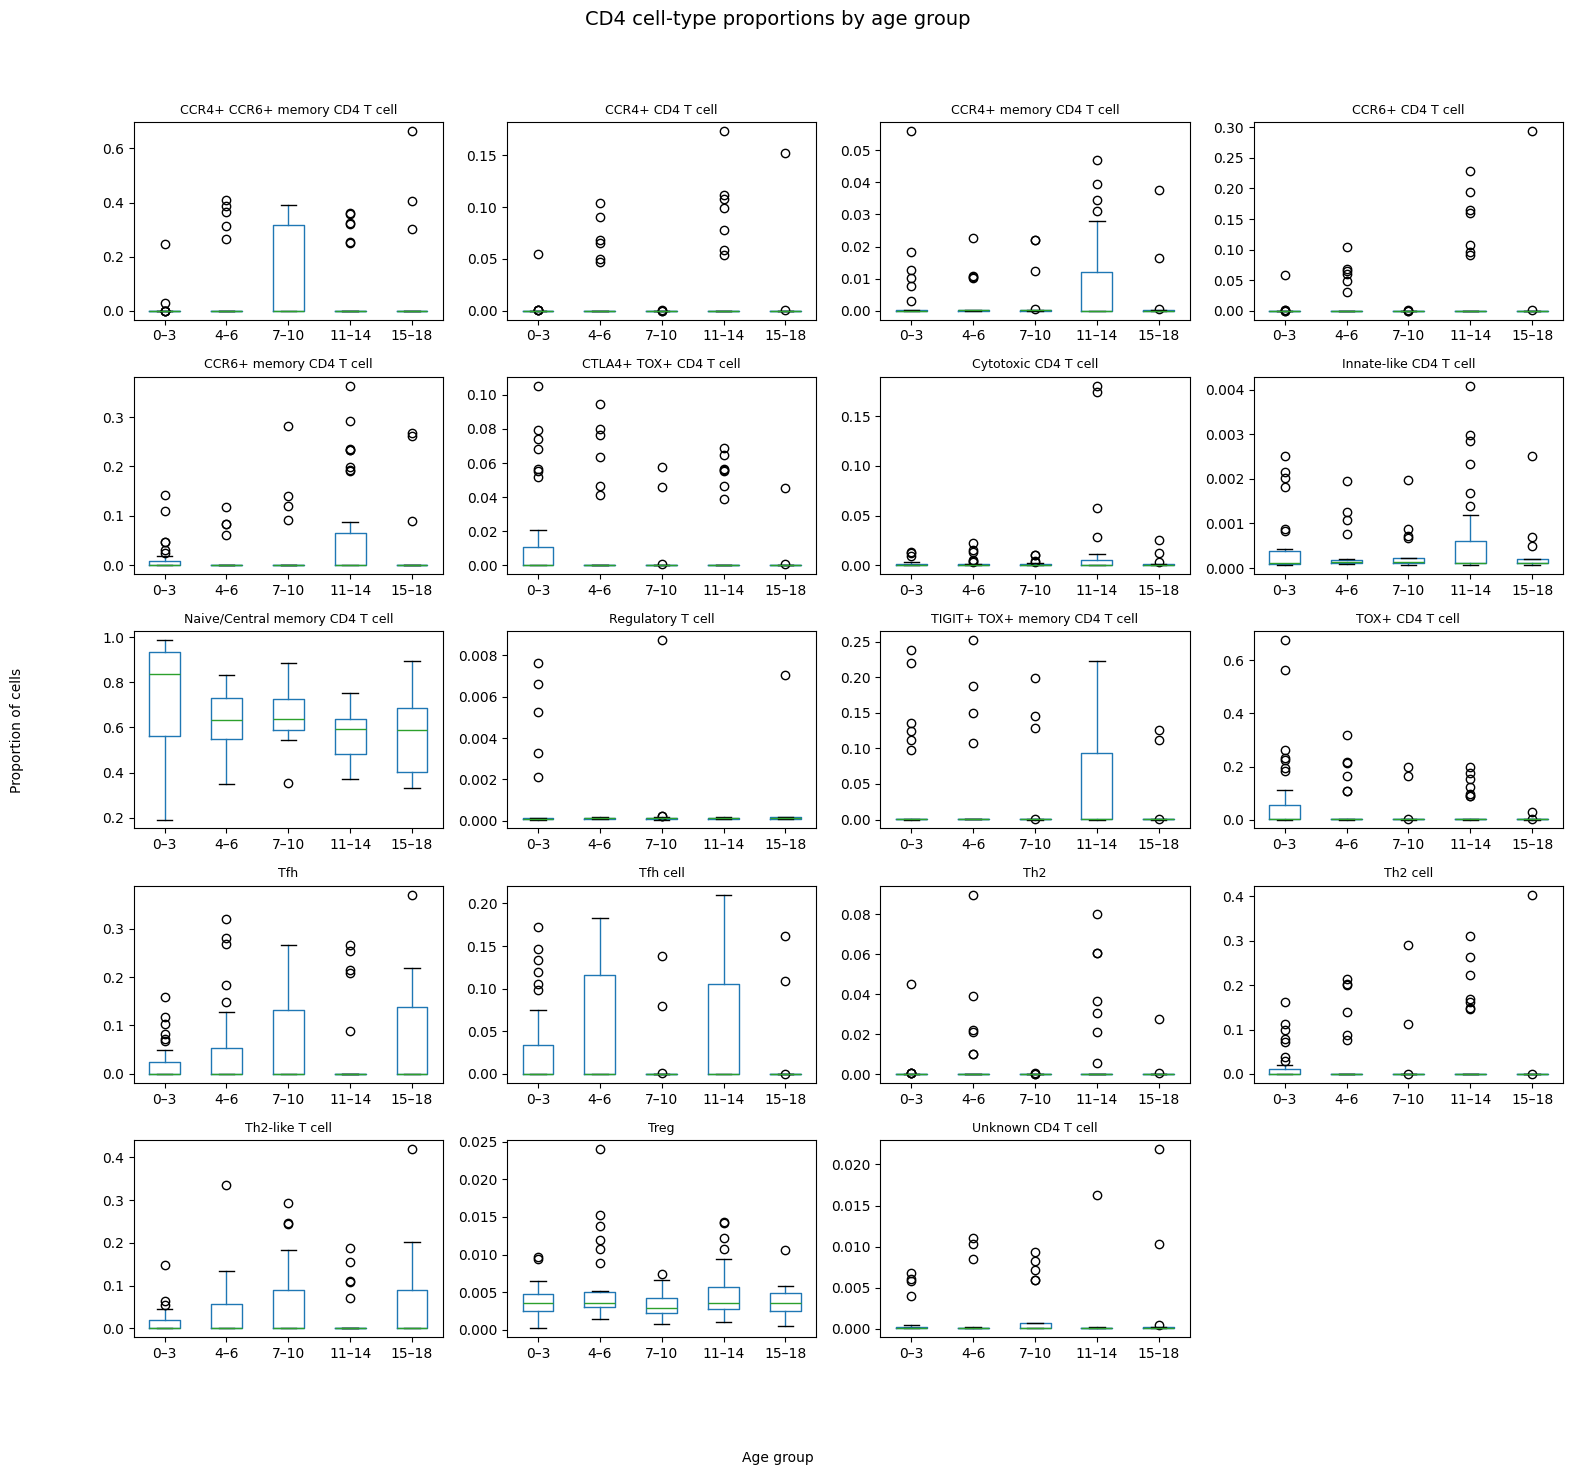

In [28]:
# boxplots of relative abundances per donor per age group
cell_types = sorted(df["Cell Type"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df[df["Cell Type"] == cell]
    sub.boxplot(
        column="Proportion",
        by="Age_group",
        grid=False,
        ax=ax
    )
    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

plt.suptitle("CD4 cell-type proportions by age group", fontsize=14)
fig.supxlabel("Age group", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()

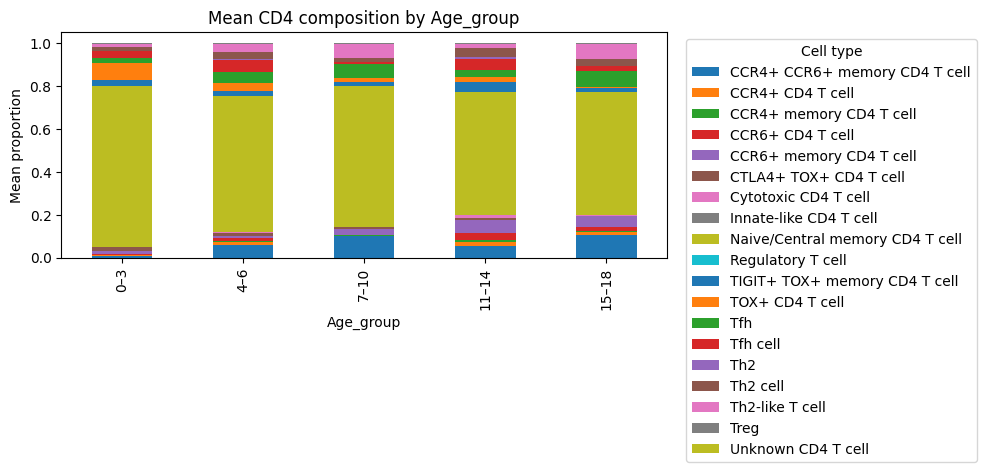

In [29]:
# barplot of composition by age group
props_age = props.join(meta["Age_group"]).groupby("Age_group").mean()

ax = props_age.plot(kind="bar", stacked=True, figsize=(10, 4))
ax.set_xlabel("Age_group")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean CD4 composition by Age_group")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Cell type")
plt.tight_layout()
plt.show()

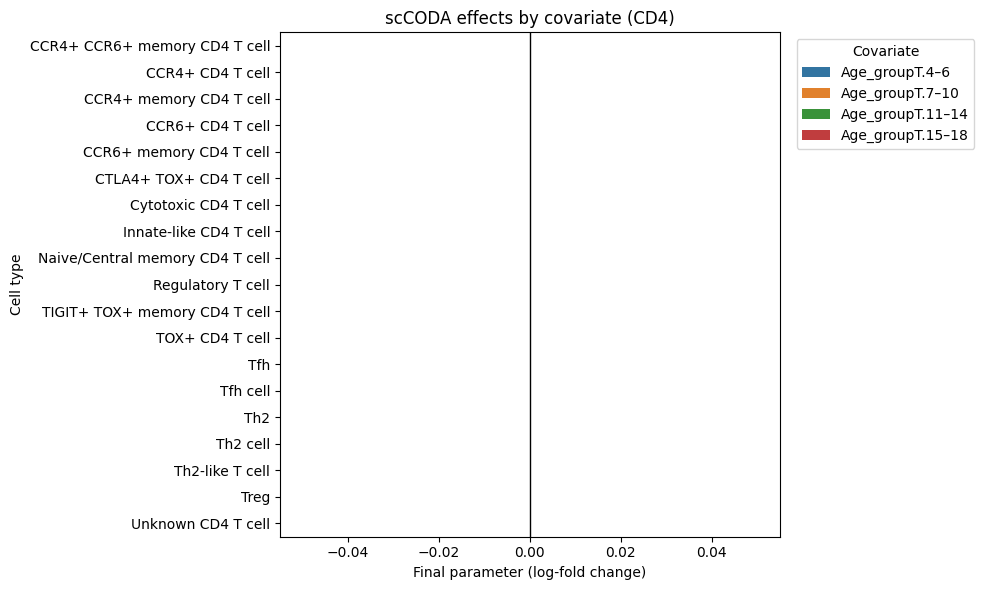

In [31]:
# effect barplot (may need to check your pertpy version)
plt.figure(figsize=(10, 6))

sns.barplot(
    data=effects_cd4,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    orient="h"
)

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Final parameter (log-fold change)")
plt.ylabel("Cell type")
plt.title("scCODA effects by covariate (CD4)")
plt.legend(title="Covariate", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

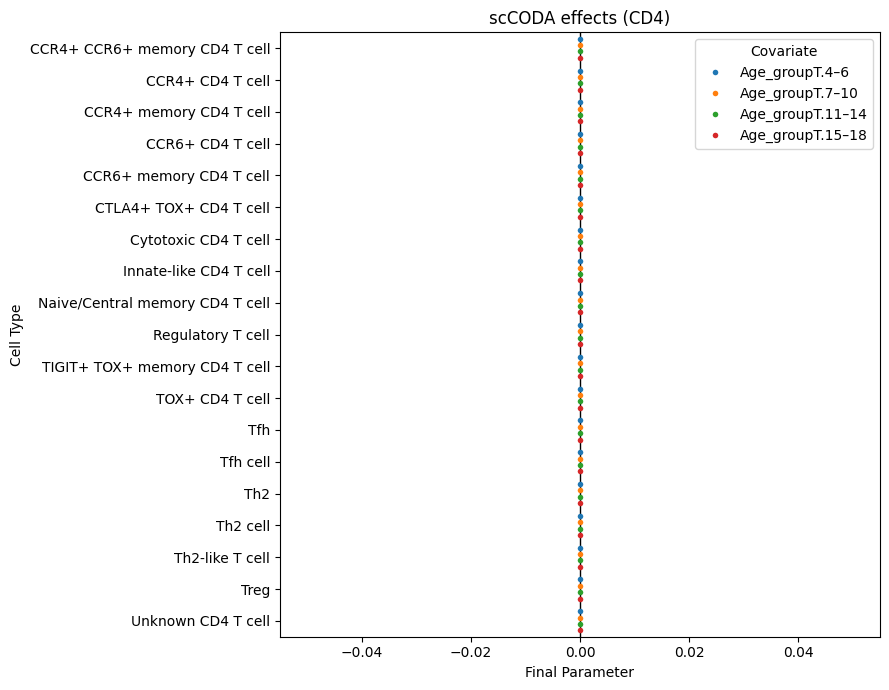

In [33]:
plt.figure(figsize=(9, 7))
sns.stripplot(
    data=effects_cd4,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)
plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects (CD4)")
plt.tight_layout()
plt.show()

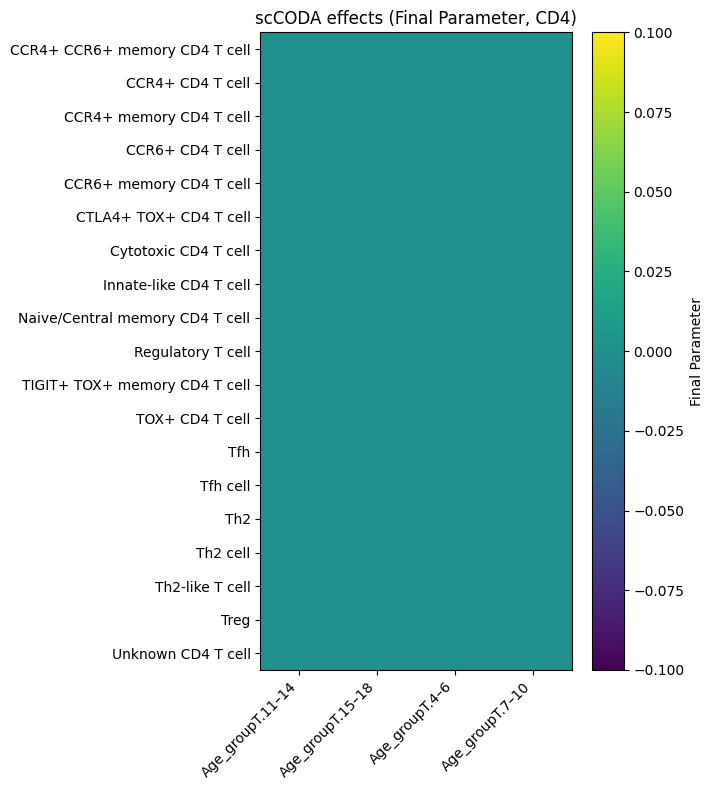

In [35]:
# inclusion pronbability heatmap
tmp = effects_cd4.reset_index()
ip = tmp.pivot(index="Cell Type", columns="Covariate", values="Inclusion probability")

beta = effects_cd4["Final Parameter"].unstack("Covariate")

plt.figure(figsize=(7, 8))
plt.imshow(beta.values, aspect="auto")
plt.yticks(range(beta.shape[0]), beta.index)
plt.xticks(range(beta.shape[1]), beta.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter")
plt.title("scCODA effects (Final Parameter, CD4)")
plt.tight_layout()
plt.show()

### absence of directional effects

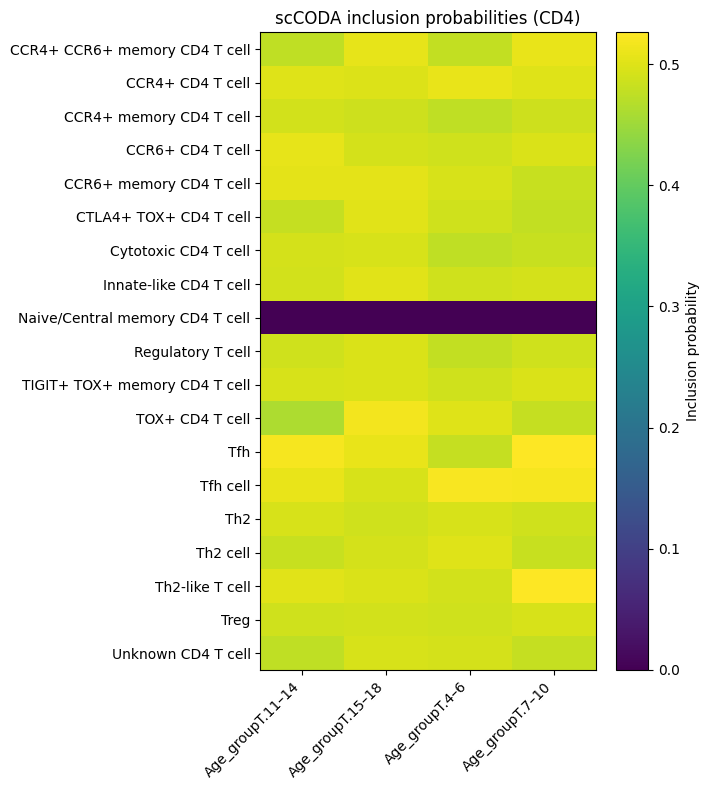

In [36]:
ip = effects_cd4["Inclusion probability"].unstack("Covariate")
# now rows = Cell Type, cols = Covariate

plt.figure(figsize=(7, 8))
plt.imshow(ip.values, aspect="auto")
plt.yticks(range(ip.shape[0]), ip.index)
plt.xticks(range(ip.shape[1]), ip.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities (CD4)")
plt.tight_layout()
plt.show()


### lack of statistical support

## Age + sex model

In [39]:
sccoda_cd4["coda"].obs.columns


Index(['pica_id', 'Age_group', 'Child's sex'], dtype='object')

In [43]:
sccoda_cd4["coda"].obs = sccoda_cd4["coda"].obs.rename(columns={"Child's sex": "Child_sex"})


In [44]:
# prepare sccoda model
def prepare_sccoda_age_sex(sccoda_data, modality_key="coda"):
    formula = "Age_group + Child_sex"
    return sccoda_model.prepare(
        sccoda_data,
        modality_key=modality_key,
        formula=formula,
        reference_cell_type="automatic",
    )
    return sccoda_data

In [45]:
sccoda_cd4_age_sex = sccoda_cd4.copy()

In [46]:
## run sccoda
sccoda_cd4_age_sex = prepare_sccoda_age_sex(sccoda_cd4_age_sex)
sccoda_cd4_age_sex = run_sccoda(sccoda_cd4_age_sex, rng_key=1)

• Automatic reference selection! Reference cell type set to Innate-like CD4 T cell


sample: 100%|██████████| 7000/7000 [05:11<00:00, 22.50it/s, 127 steps of size 4.40e-02. acc. prob=0.70]


In [47]:
sccoda_model.summary(sccoda_cd4_age_sex, modality_key="coda", extended=True)
effects_cd4_age_sex = sccoda_model.get_effect_df(sccoda_cd4_age_sex, modality_key="coda")
effects_cd4_age_sex.head()

                                          Compositional Analysis summary                                           
┌───────────────────────────────────────┬─────────────────────────────────────────────────────────────────────────┐
│ Name                                  │ Value                                                                   │
├───────────────────────────────────────┼─────────────────────────────────────────────────────────────────────────┤
│ Data                                  │ Data: 128 samples, 19 cell types                                        │
│ Reference cell type                   │ Innate-like CD4 T cell                                                  │
│ Formula                               │ Age_group + Child_sex                                                   │
│ Reference index                       │ 7                                                                       │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ Spike-and-slab threshold              │ 1.000                                                                   │
│ MCMC Sampling                         │ Sampled 5000 chain states (2000 burnin samples)                         │
│ Acceptance rate                       │ 69.8%                                                                   │
└───────────────────────────────────────┴─────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Intercepts                                                                                                      │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                  Final Parameter  HDI 3%  HDI 97%   SD   Expected Sample                        │
│ cell_type                                                                                                       │
│ CCR4+ CCR6+ memory CD4 T cell        -1.750       -1.930  -1.561  0.099       83.570                            │
│ CCR4+ CD4 T cell                     -1.857       -2.039  -1.664  0.100       75.090                            │
│ CCR4+ memory CD4 T cell              -1.809       -2.001  -1.623  0.101       78.782                            │
│ CCR6+ CD4 T cell                     -1.855       -2.039  -1.666  0.100       75.240                            │
│ CCR6+ memory CD4 T cell              -1.701       -1.879  -1.506  0.098       87.767                            │
│ CTLA4+ TOX+ CD4 T cell               -1.765       -1.950  -1.577  0.100       82.326                            │
│ Cytotoxic CD4 T cell                 -1.744       -1.937  -1.563  0.100       84.073                            │
│ Innate-like CD4 T cell               -1.892       -2.067  -1.724  0.092       72.507                            │
│ Naive/Central memory CD4 T cell       1.756        1.593   1.914  0.086     2784.106                            │
│ Regulatory T cell                    -1.957       -2.142  -1.765  0.100       67.944                            │
│ TIGIT+ TOX+ memory CD4 T cell        -1.735       -1.946  -1.549  0.105       84.833                            │
│ TOX+ CD4 T cell                      -1.729       -1.927  -1.546  0.101       85.343                            │
│ Tfh                                  -1.624       -1.826  -1.427  0.106       94.792                            │
│ Tfh cell                             -1.571       -1.769  -1.379  0.104       99.951                            │
│ Th2                                  -1.875       -2.066  -1.695  0.098       73.750                            │
│ Th2 cell                             -1.740       -1.932  -1.551  0.100       84.410                            │
│ Th2-like T cell                      -1.642       -1.839  -1.445  0.107       93.101                            │
│ Treg                                 -1.220       -1.392  -1.040  0.096      141.979                            │
│ Unknown CD4 T cell                   -1.899       -2.094  -1.713  0.101       72.001                            │
└─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects                                                                                                         │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                   Final Parameter  Expected Sample  log2-fold change            │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   CCR4+ CCR6+ memory CD4 T cell        0.000             83.570           0.000                  │
│                  CCR4+ CD4 T cell                     0.000             75.090           0.000                  │
│                  CCR4+ memory CD4 T cell              0.000             78.782           0.000                  │
│                  CCR6+ CD4 T cell                     0.000             75.240           0.000                  │
│                  CCR6+ memory CD4 T cell              0.000             87.767           0.000                  │
│                  CTLA4+ TOX+ CD4 T cell               0.000             82.326           0.000                  │
│                  Cytotoxic CD4 T cell                 0.000             84.073           0.000                  │
│                  Innate-like CD4 T cell               0.000             72.507           0.000                  │
│                  Naive/Central memory CD4 T cell      0.000           2784.106           0.000                  │
│                  Regulatory T cell                    0.000             67.944           0.000                  │
│                  TIGIT+ TOX+ memory CD4 T cell        0.000             84.833           0.000                  │
│                  TOX+ CD4 T cell                      0.000             85.343           0.000                  │
│                  Tfh                                  0.000             94.792           0.000                  │
│                  Tfh cell                             0.000             99.951           0.000                  │
│                  Th2                                  0.000             73.750           0.000                  │
│                  Th2 cell                             0.000             84.410           0.000                  │
│                  Th2-like T cell                      0.000             93.101           0.000                  │
│                  Treg                                 0.000            141.979           0.000                  │
│                  Unknown CD4 T cell                   0.000             72.001           0.000                  │
│ Age_groupT.7–10  CCR4+ CCR6+ memory CD4 T cell        0.000             83.570           0.000                  │
│                  CCR4+ CD4 T cell                     0.000             75.090           0.000                  │
│                  CCR4+ memory CD4 T cell              0.000             78.782           0.000                  │
│                  CCR6+ CD4 T cell                     0.000             75.240           0.000                  │
│                  CCR6+ memory CD4 T cell              0.000             87.767           0.000                  │
│                  CTLA4+ TOX+ CD4 T cell               0.000             82.326           0.000                  │
│                  Cytotoxic CD4 T cell                 0.000             84.073           0.000                  │
│                  Innate-like CD4 T cell               0.000             72.507           0.000                  │
│                  Naive/Central memory CD4 T cell      0.000           2784.106           0.000                  │
│                  Regulatory T cell                    0.000             67.944           0.000                  │
│                  TIGIT+ TOX+ memory CD4 T cell        

┌─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Effects Extended                                                                                                │
├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│                                                   HDI 3%  HDI 97%   SD   Inclusion probability                  │
│ Covariate        Cell Type                                                                                      │
│ Age_groupT.4–6   CCR4+ CCR6+ memory CD4 T cell    -0.149  0.151   0.055         0.480                           │
│                  CCR4+ CD4 T cell                 -0.128  0.185   0.059         0.498                           │
│                  CCR4+ memory CD4 T cell          -0.165  0.135   0.054         0.497                           │
│                  CCR6+ CD4 T cell                 -0.122  0.184   0.057         0.495                           │
│                  CCR6+ memory CD4 T cell          -0.195  0.116   0.059         0.500                           │
│                  CTLA4+ TOX+ CD4 T cell           -0.157  0.148   0.056         0.499                           │
│                  Cytotoxic CD4 T cell             -0.170  0.127   0.054         0.490                           │
│                  Innate-like CD4 T cell            0.000  0.000   0.000         0.000                           │
│                  Naive/Central memory CD4 T cell  -0.158  0.106   0.047         0.477                           │
│                  Regulatory T cell                -0.149  0.135   0.053         0.492                           │
│                  TIGIT+ TOX+ memory CD4 T cell    -0.156  0.145   0.056         0.494                           │
│                  TOX+ CD4 T cell                  -0.155  0.147   0.054         0.484                           │
│                  Tfh                              -0.157  0.153   0.056         0.494                           │
│                  Tfh cell                         -0.121  0.206   0.066         0.524                           │
│                  Th2                              -0.125  0.188   0.058         0.491                           │
│                  Th2 cell                         -0.151  0.150   0.056         0.493                           │
│                  Th2-like T cell                  -0.148  0.147   0.054         0.488                           │
│                  Treg                             -0.125  0.163   0.054         0.502                           │
│                  Unknown CD4 T cell               -0.155  0.138   0.053         0.484                           │
│ Age_groupT.7–10  CCR4+ CCR6+ memory CD4 T cell    -0.127  0.302   0.086         0.507                           │
│                  CCR4+ CD4 T cell                 -0.221  0.164   0.072         0.488                           │
│                  CCR4+ memory CD4 T cell          -0.200  0.179   0.066         0.481                           │
│                  CCR6+ CD4 T cell                 -0.214  0.157   0.070         0.496                           │
│                  CCR6+ memory CD4 T cell          -0.208  0.168   0.067         0.488                           │
│                  CTLA4+ TOX+ CD4 T cell           -0.214  0.172   0.070         0.488                           │
│                  Cytotoxic CD4 T cell             -0.182  0.175   0.064         0.470                           │
│                  Innate-like CD4 T cell            0.000  0.000   0.000         0.000                           │
│                  Naive/Central memory CD4 T cell  -0.112  0.213   0.059         0.480                           │
│                  Regulatory T cell                -0.146  0.211   0.065         0.492                           │
│                  TIGIT+ TOX+ memory CD4 T cell    -0.1

Final Parameter  HDI 3%  \
Covariate      Cell Type                                                
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell              0.0  -0.149   
               CCR4+ CD4 T cell                           0.0  -0.128   
               CCR4+ memory CD4 T cell                    0.0  -0.165   
               CCR6+ CD4 T cell                           0.0  -0.122   
               CCR6+ memory CD4 T cell                    0.0  -0.195   

                                              HDI 97%     SD  \
Covariate      Cell Type                                       
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell    0.151  0.055   
               CCR4+ CD4 T cell                 0.185  0.059   
               CCR4+ memory CD4 T cell          0.135  0.054   
               CCR6+ CD4 T cell                 0.184  0.057   
               CCR6+ memory CD4 T cell          0.116  0.059   

                                              Inclusion probability  \
Covariate      Cell Type                                              
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell                 0.4802   
               CCR4+ CD4 T cell                              0.4978   
               CCR4+ memory CD4 T cell                       0.4970   
               CCR6+ CD4 T cell                              0.4946   
               CCR6+ memory CD4 T cell                       0.5000   

                                              Expected Sample  \
Covariate      Cell Type                                        
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell        83.569780   
               CCR4+ CD4 T cell                     75.089593   
               CCR4+ memory CD4 T cell              78.781797   
               CCR6+ CD4 T cell                     75.239922   
               CCR6+ memory CD4 T cell              87.766684   

                                              log2-fold change  
Covariate      Cell Type                                        
Age_groupT.4–6 CCR4+ CCR6+ memory CD4 T cell               0.0  
               CCR4+ CD4 T cell                            0.0  
               CCR4+ memory CD4 T cell                     0.0  
               CCR6+ CD4 T cell                            0.0  
               CCR6+ memory CD4 T cell                     0.0

In [48]:
# counts per sample x celltype
counts = pd.DataFrame(
    sccoda_cd4_age_sex["coda"].X,
    index=sccoda_cd4_age_sex["coda"].obs_names,
    columns=sccoda_cd4_age_sex["coda"].var_names,
)

# convert to proportions per sample (row)
props = counts.div(counts.sum(axis=1), axis=0)

# metadata (sample-level)
meta = sccoda_cd4_age_sex["coda"].obs.copy()

df_age_sex = (
    props
    .join(meta[["Age_group", "Child_sex"]])   
    .reset_index(names="sample")
    .melt(
        id_vars=["sample", "Age_group", "Child_sex"],  
        var_name="Cell Type",
        value_name="Proportion",
    )
)

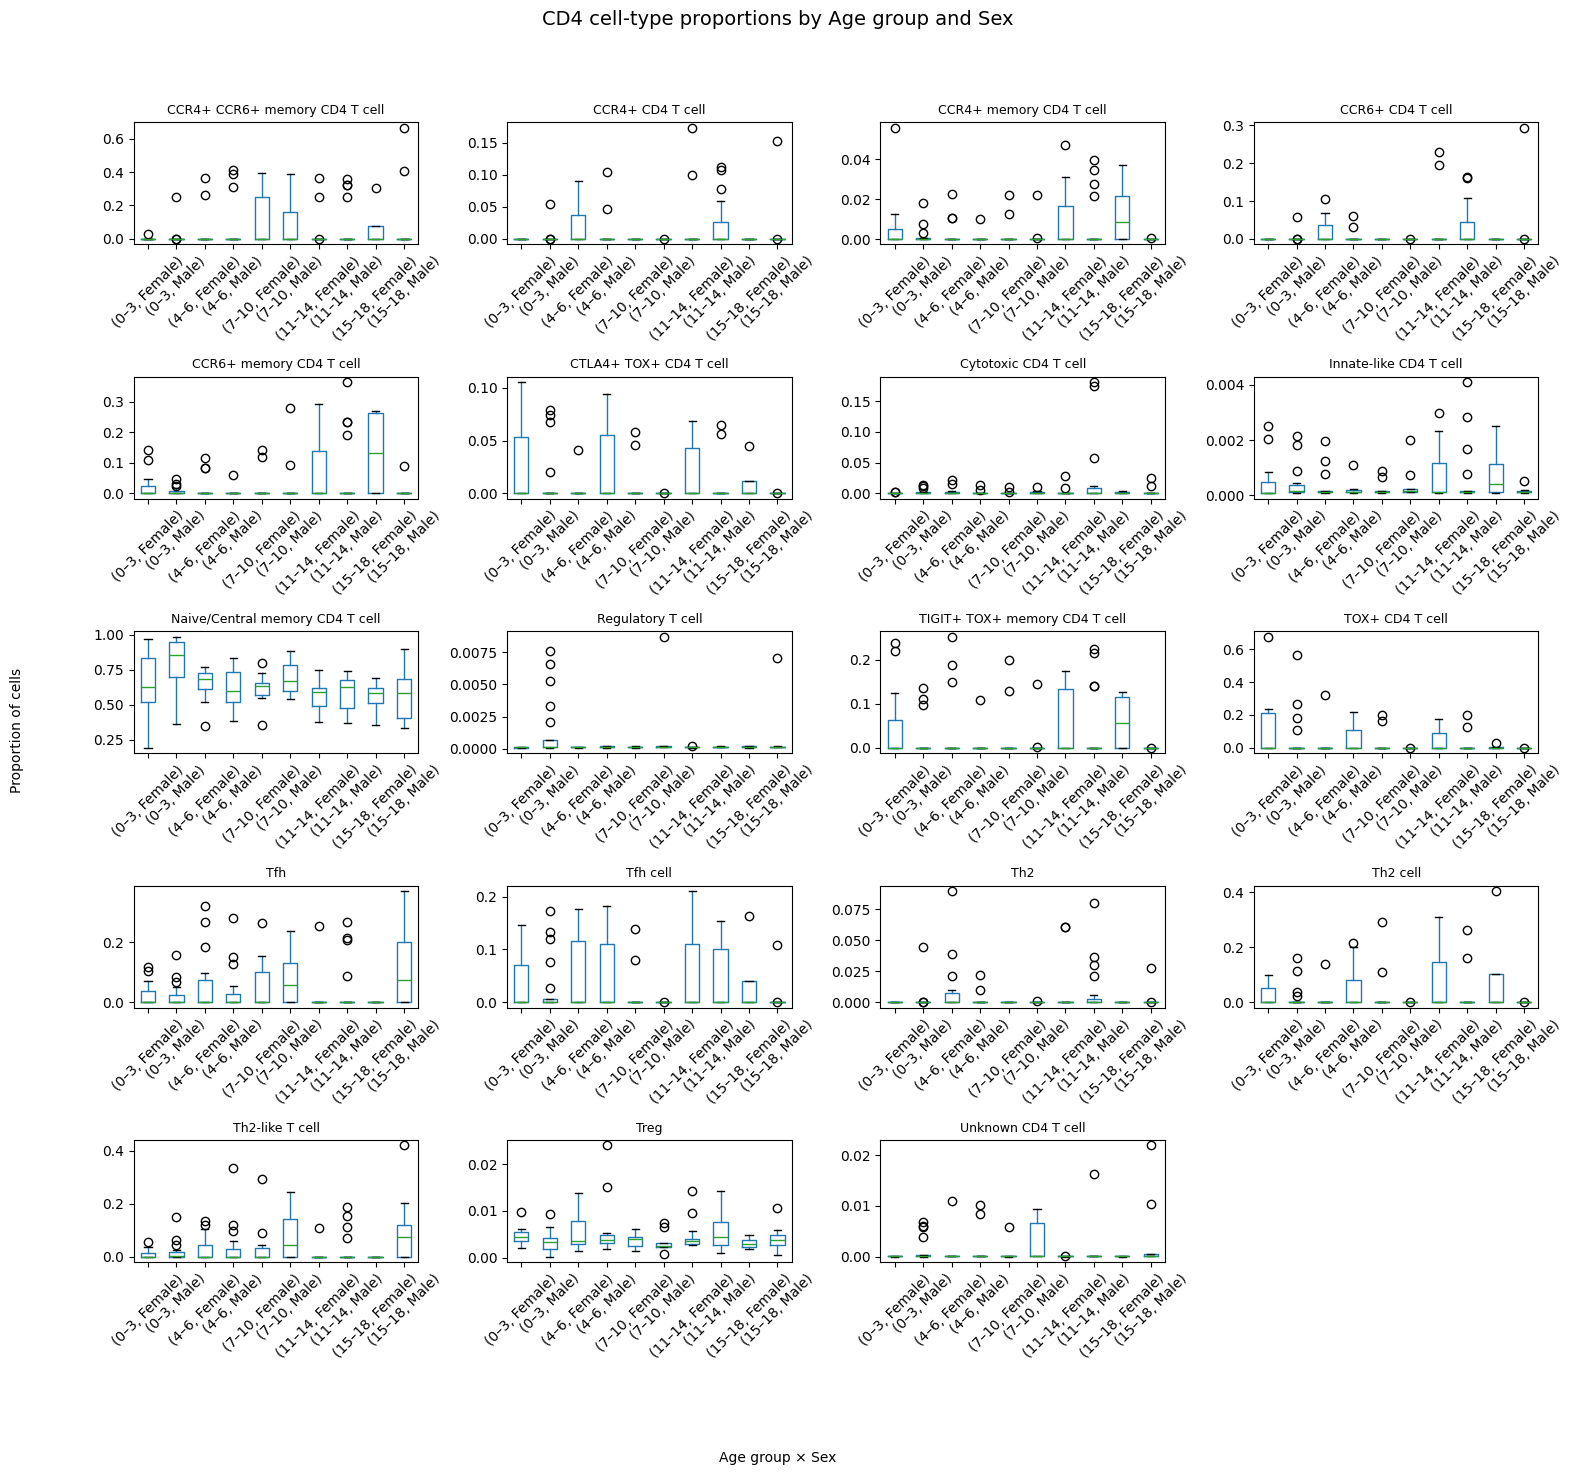

In [49]:
cell_types = sorted(df_age_sex["Cell Type"].unique())

n_cols = 4
n_rows = math.ceil(len(cell_types) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
axes = axes.flatten()

for ax, cell in zip(axes, cell_types):
    sub = df_age_sex[df_age_sex["Cell Type"] == cell]

    # grouped boxplot: Age_group on x, split by Sex
    # pandas boxplot supports grouping via `by=[...]`
    sub.boxplot(
        column="Proportion",
        by=["Age_group", "Child_sex"],
        grid=False,
        ax=ax,
        rot=45,
    )

    ax.set_title(cell, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("")

# remove empty panels
for ax in axes[len(cell_types):]:
    ax.axis("off")

# IMPORTANT: pandas boxplot adds an automatic suptitle; remove it
plt.suptitle("")

fig.suptitle("CD4 cell-type proportions by Age group and Sex", fontsize=14)
fig.supxlabel("Age group × Sex", fontsize=10)
fig.supylabel("Proportion of cells", fontsize=10)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
plt.show()


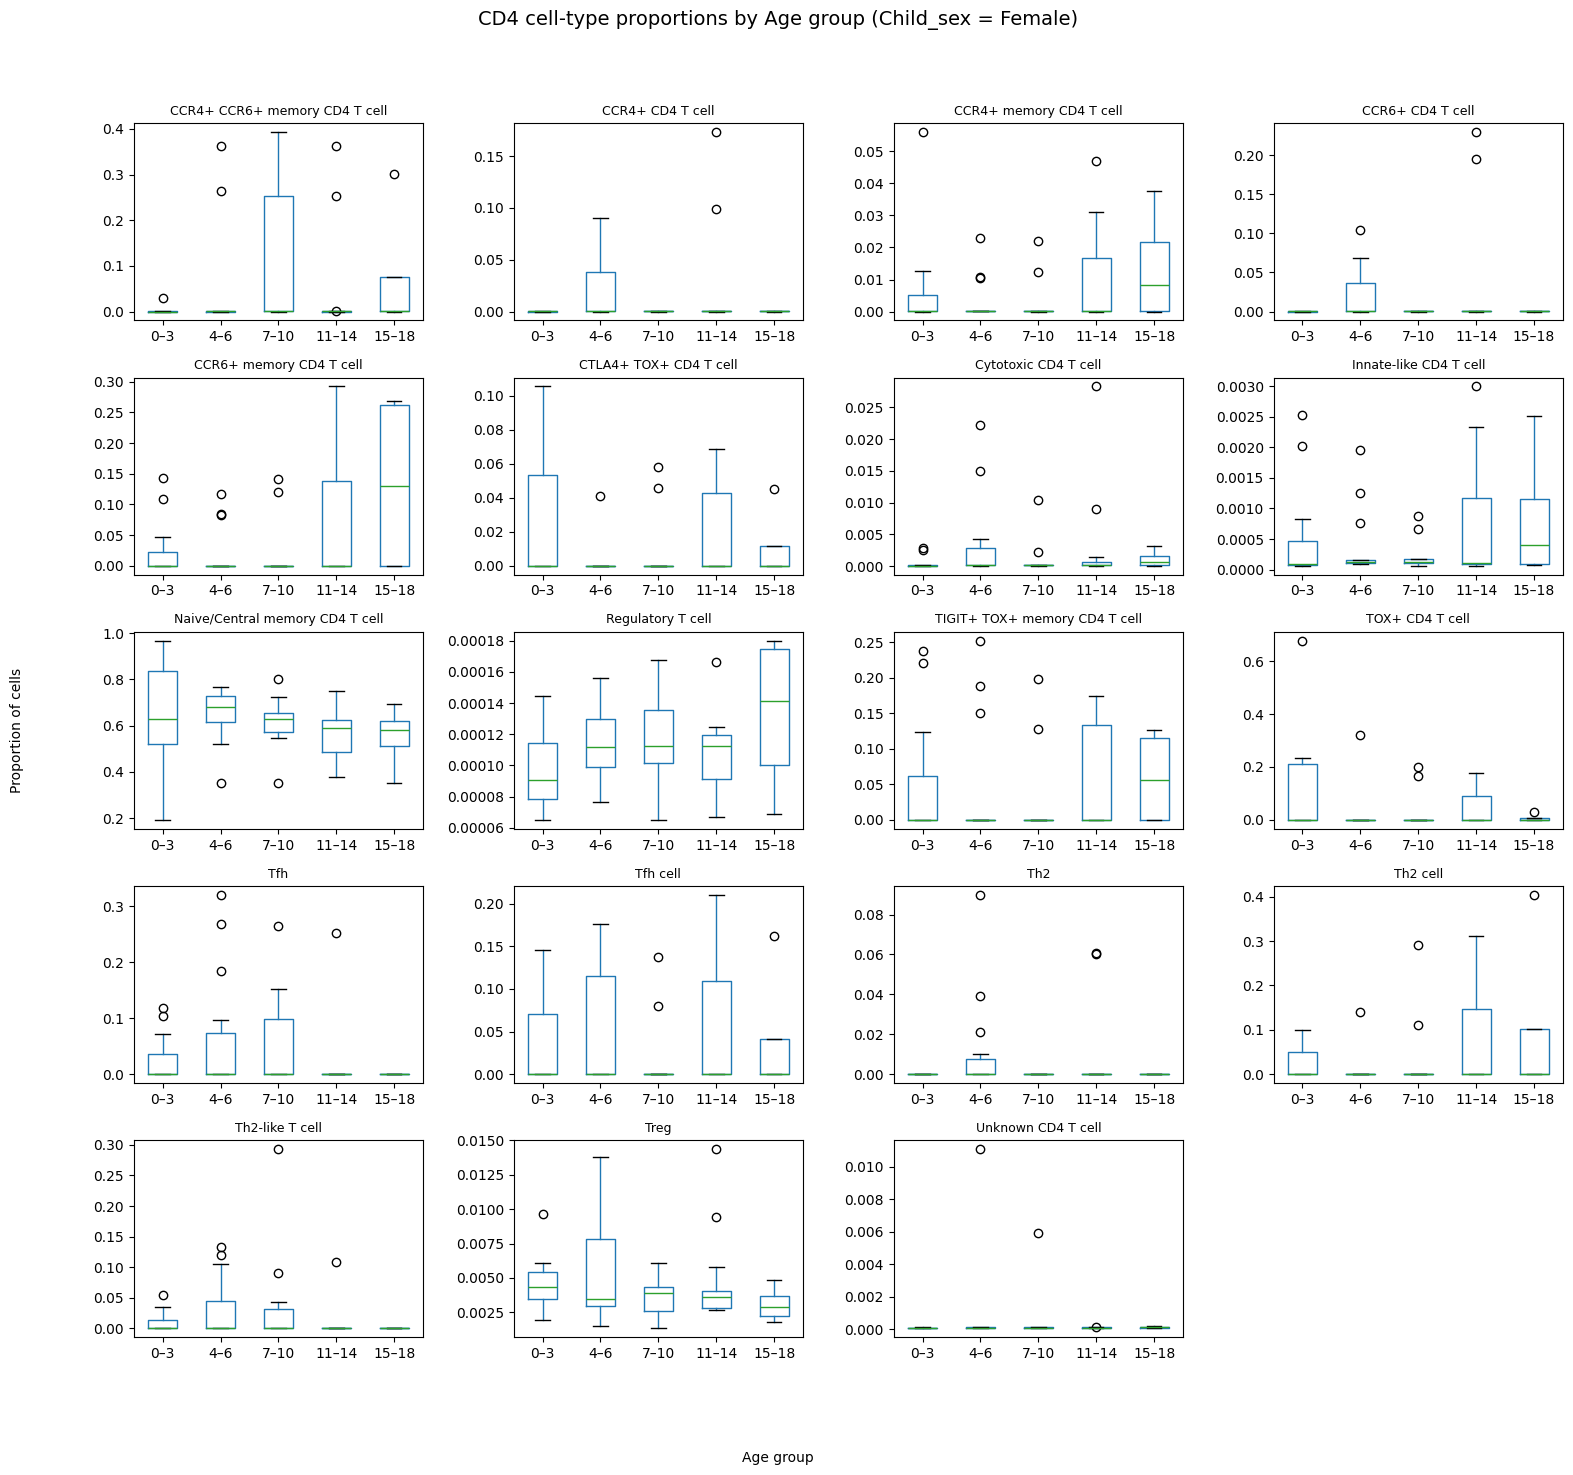

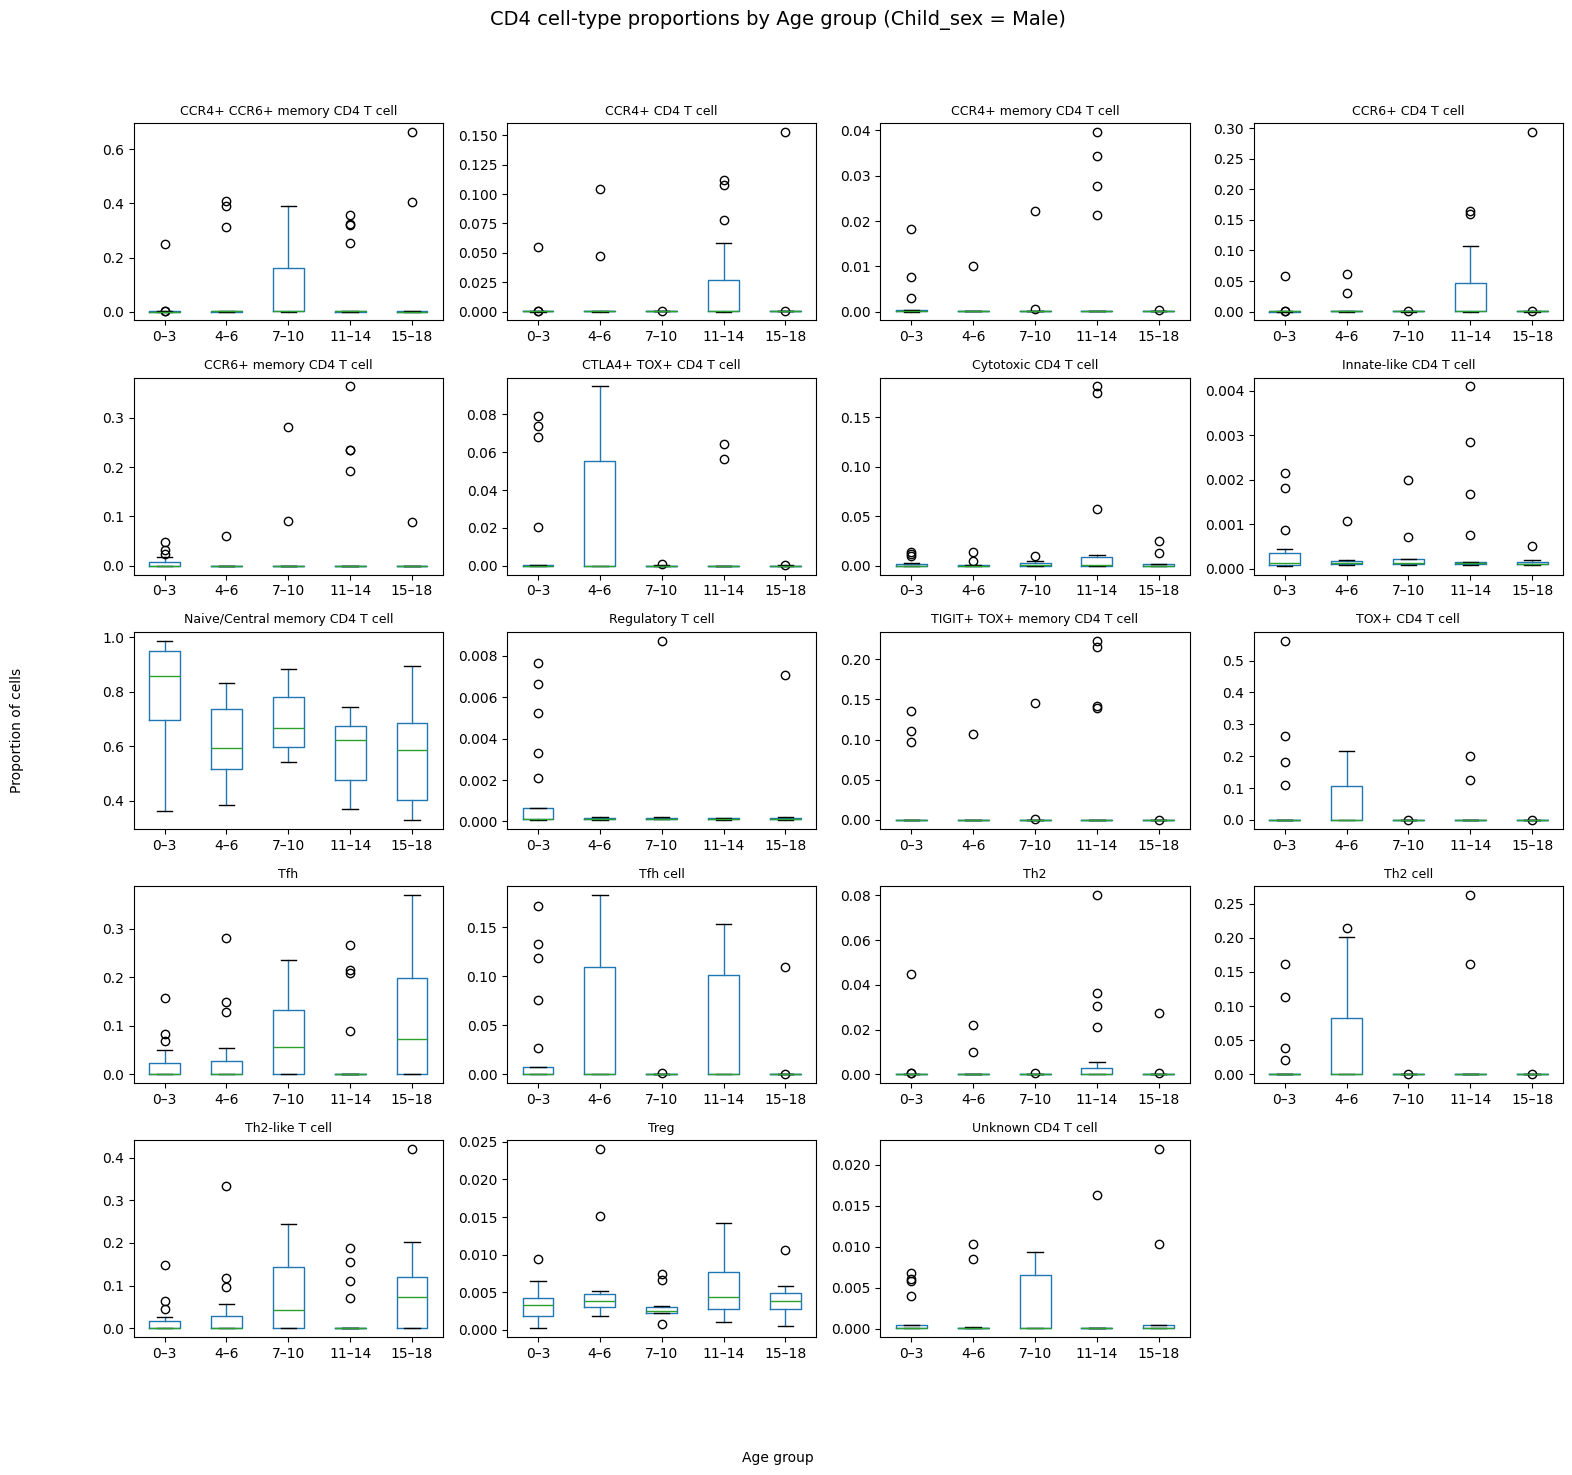

In [ ]:
SEX_COL = "Child_sex"  

# get ordered sex levels robustly
sex_series = df_age_sex[SEX_COL]
sex_levels = (
    list(sex_series.cat.categories) if pd.api.types.is_categorical_dtype(sex_series)
    else sorted(sex_series.dropna().unique())
)

for sex in sex_levels:
    df_sex = df_age_sex[df_age_sex[SEX_COL] == sex].copy()

    cell_types = sorted(df_sex["Cell Type"].unique())
    n_cols = 4
    n_rows = math.ceil(len(cell_types) / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, cell in zip(axes, cell_types):
        sub = df_sex[df_sex["Cell Type"] == cell]
        sub.boxplot(column="Proportion", by="Age_group", grid=False, ax=ax)

        ax.set_title(cell, fontsize=9)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # turn off unused panels
    for ax in axes[len(cell_types):]:
        ax.axis("off")

    # remove pandas' automatic "by=..." title
    fig.suptitle(f"CD4 cell-type proportions by Age group ({SEX_COL} = {sex})", fontsize=14)
    fig.supxlabel("Age group", fontsize=10)
    fig.supylabel("Proportion of cells", fontsize=10)

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.95])
    plt.show()

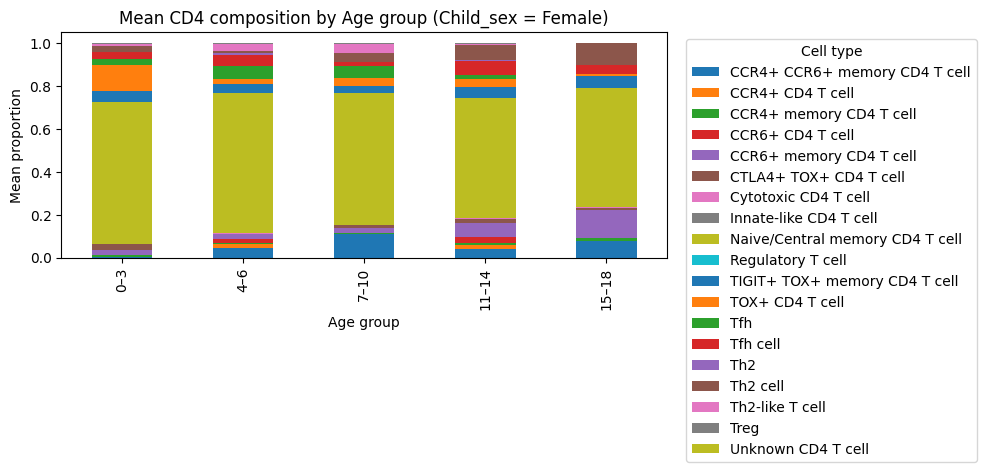

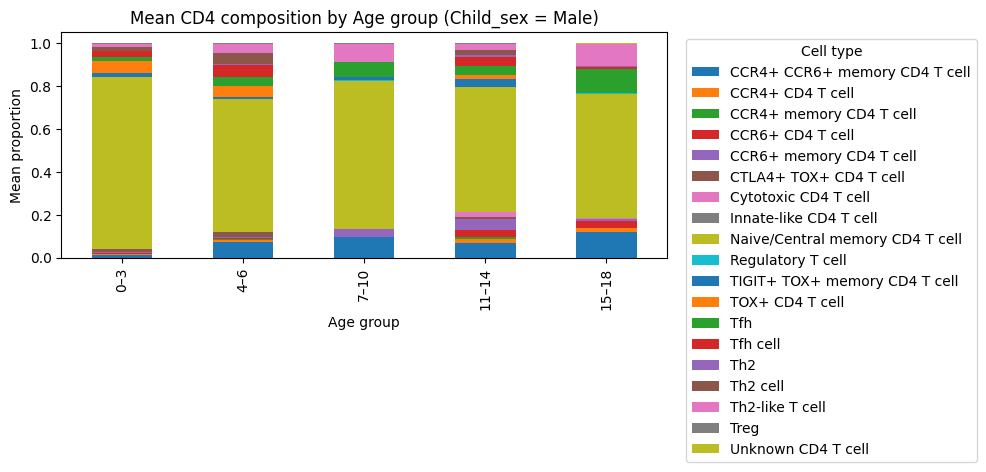

In [51]:
# mean composition per Age_group × Sex
props_age_sex = (
    props
    .join(meta[["Age_group", SEX_COL]])
    .groupby(["Age_group", SEX_COL])
    .mean()
)

for sex in props_age_sex.index.get_level_values(SEX_COL).unique():
    df_plot = props_age_sex.xs(sex, level=SEX_COL)

    ax = df_plot.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 4)
    )

    ax.set_xlabel("Age group")
    ax.set_ylabel("Mean proportion")
    ax.set_title(f"Mean CD4 composition by Age group ({SEX_COL} = {sex})")

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        title="Cell type"
    )

    plt.tight_layout()
    plt.show()

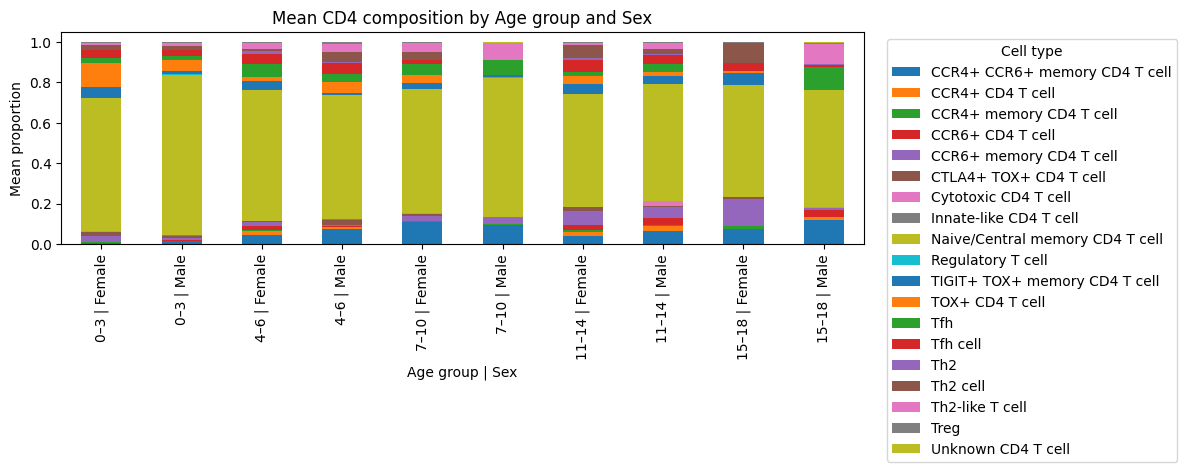

In [52]:
# combine index for plotting
props_age_sex.index = props_age_sex.index.map(
    lambda x: f"{x[0]} | {x[1]}"
)

ax = props_age_sex.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 4)
)

ax.set_xlabel("Age group | Sex")
ax.set_ylabel("Mean proportion")
ax.set_title("Mean CD4 composition by Age group and Sex")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    title="Cell type"
)

plt.tight_layout()
plt.show()

In [55]:
effects = effects_cd4_age_sex.reset_index().copy()

effects["Covariate_type"] = effects["Covariate"].apply(
    lambda x: "Age_group" if str(x).startswith("Age_group") else "Sex")

In [56]:
effects.columns
effects[["Covariate","Cell Type","Covariate_type"]].head()


,Covariate,Cell Type,Covariate_type
0,Age_groupT.4–6,CCR4+ CCR6+ memory CD4 T cell,Age_group
1,Age_groupT.4–6,CCR4+ CD4 T cell,Age_group
2,Age_groupT.4–6,CCR4+ memory CD4 T cell,Age_group
3,Age_groupT.4–6,CCR6+ CD4 T cell,Age_group
4,Age_groupT.4–6,CCR6+ memory CD4 T cell,Age_group


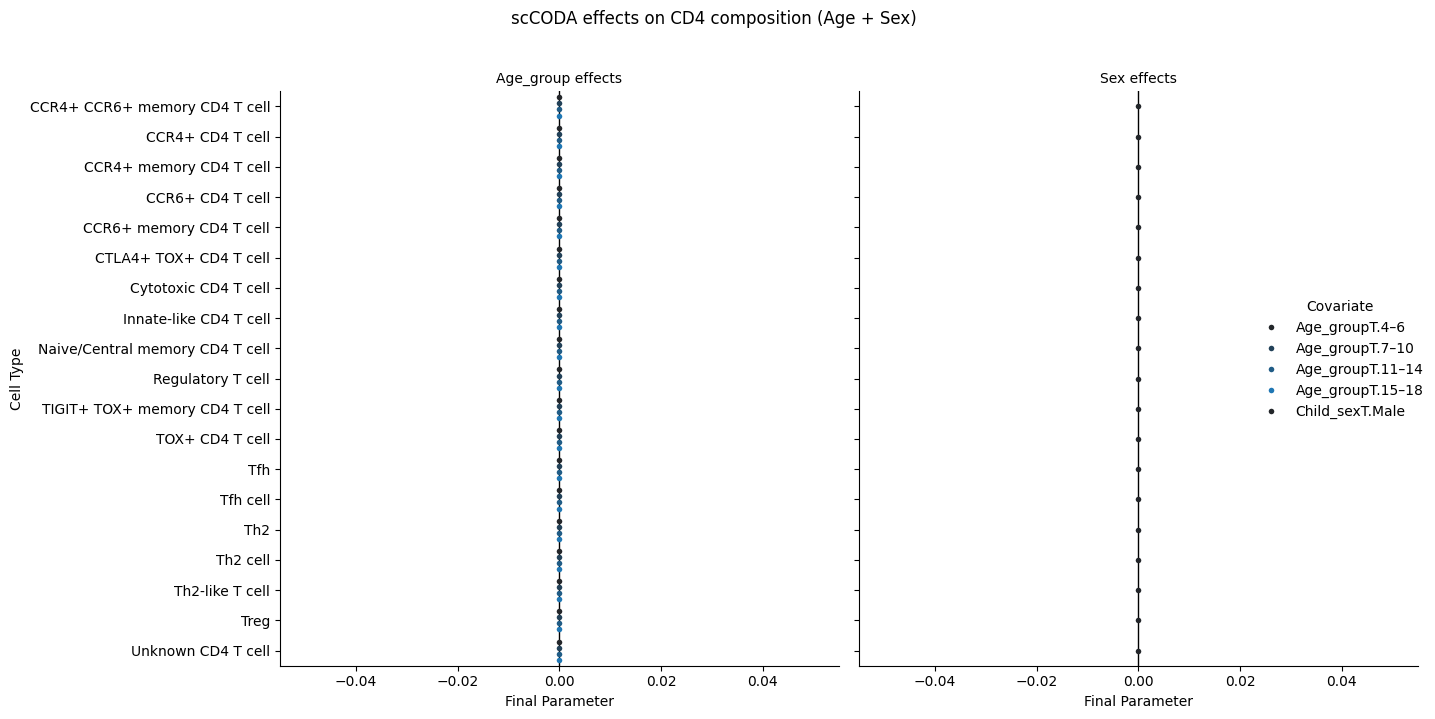

In [57]:
g = sns.FacetGrid(
    effects,
    col="Covariate_type",
    sharey=True,
    height=7,
    aspect=0.9
)

g.map_dataframe(
    sns.stripplot,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)

for ax in g.axes.flat:
    ax.axvline(0, color="black", linewidth=1)

g.add_legend(title="Covariate")
g.set_titles("{col_name} effects")
g.fig.suptitle("scCODA effects on CD4 composition (Age + Sex)", y=1.02)

plt.tight_layout()
plt.show()

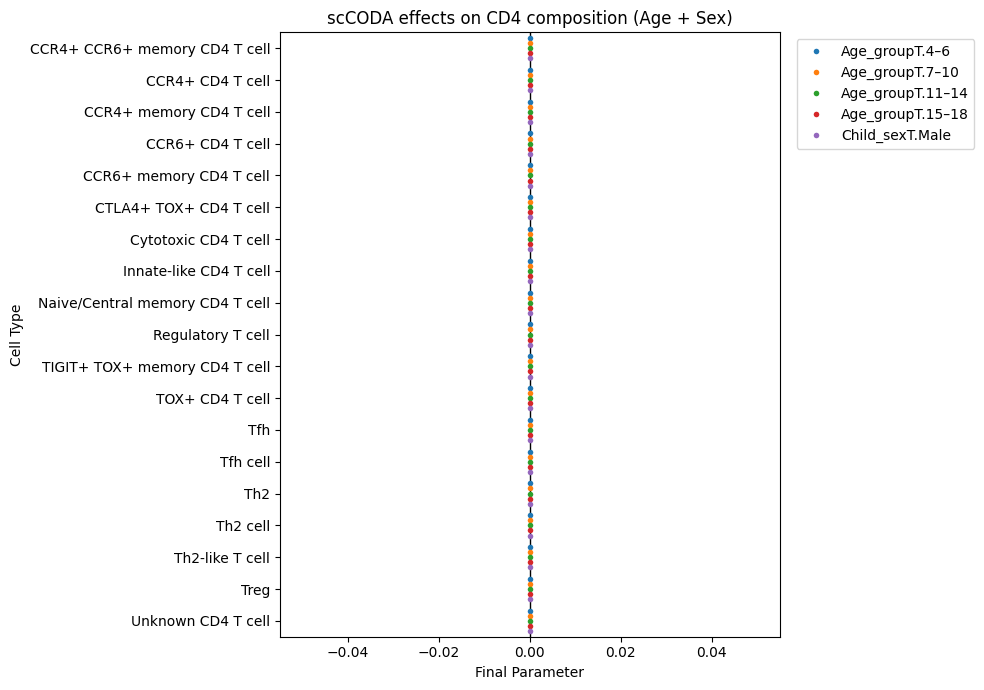

In [58]:
plt.figure(figsize=(10, 7))

sns.stripplot(
    data=effects_cd4_age_sex,
    y="Cell Type",
    x="Final Parameter",
    hue="Covariate",
    dodge=True,
    orient="h",
    size=4
)

plt.axvline(0, color="black", linewidth=1)
plt.title("scCODA effects on CD4 composition (Age + Sex)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [61]:
effects = effects_cd4_age_sex.copy()
print("index names:", effects.index.names)

index names: ['Covariate', 'Cell Type']


In [62]:
beta = effects["Final Parameter"].unstack(level=0)          # cols = covariate
ip   = effects["Inclusion probability"].unstack(level=0)    # cols = covariate

# now rows = Cell Type, cols = Covariate (flip if needed)
# If you prefer rows=Cell Type, cols=Covariate:
beta = beta.T if beta.index.name != "Cell Type" and beta.shape[0] < beta.shape[1] else beta
ip   = ip.T   if ip.index.name != "Cell Type" and ip.shape[0] < ip.shape[1] else ip

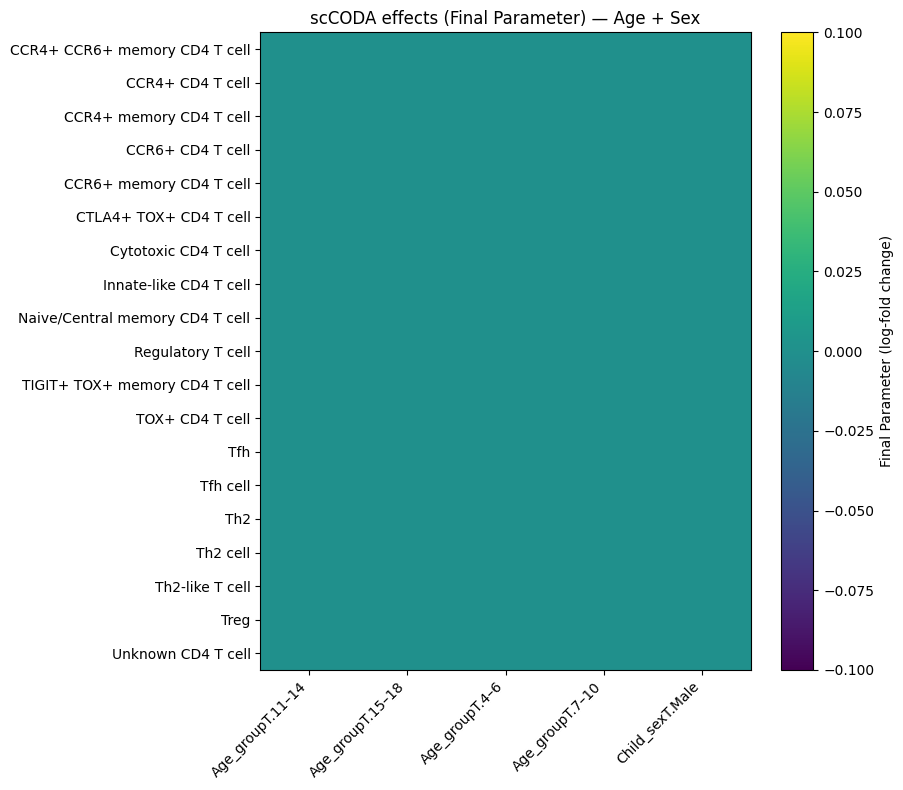

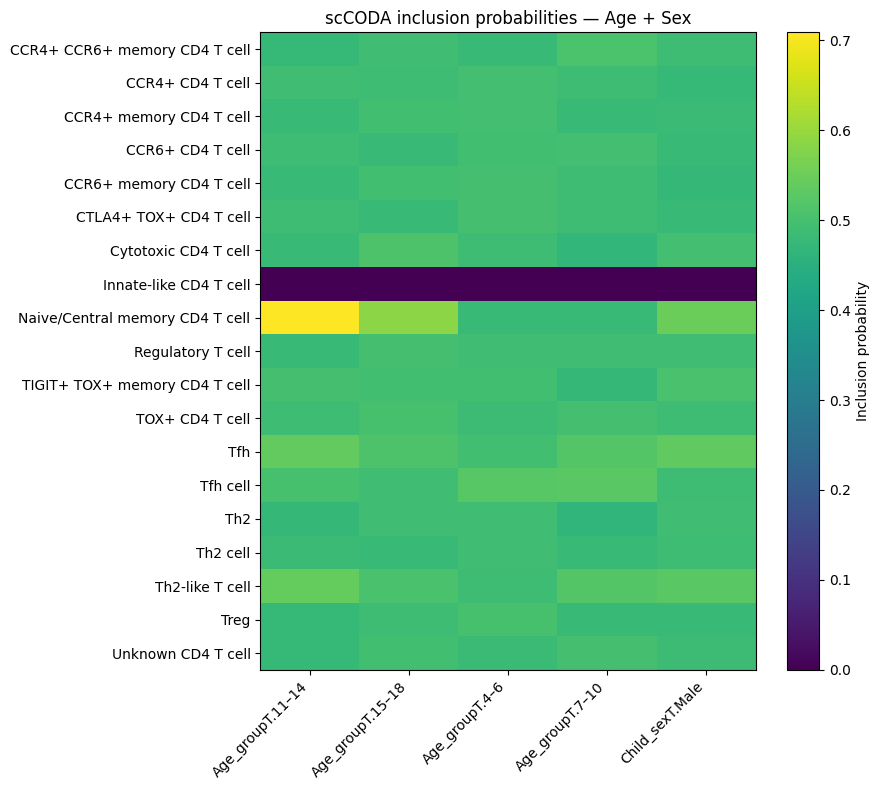

: 

In [ ]:
# Final Parameter heatmap
plt.figure(figsize=(9, 8))
plt.imshow(beta.values, aspect="auto")
plt.yticks(range(beta.shape[0]), beta.index)
plt.xticks(range(beta.shape[1]), beta.columns, rotation=45, ha="right")
plt.colorbar(label="Final Parameter (log-fold change)")
plt.title("scCODA effects (Final Parameter) — Age + Sex")
plt.tight_layout()
plt.show()

# Inclusion probability heatmap
plt.figure(figsize=(9, 8))
plt.imshow(ip.values, aspect="auto")
plt.yticks(range(ip.shape[0]), ip.index)
plt.xticks(range(ip.shape[1]), ip.columns, rotation=45, ha="right")
plt.colorbar(label="Inclusion probability")
plt.title("scCODA inclusion probabilities — Age + Sex")
plt.tight_layout()
plt.show()